In [7]:
#import libraries 
import pandas as pd 
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Imports data set with pandas
df = pd.read_stata('birthweight_smoking.dta')
# Displays the first five rows of the data set
df.head()

,nprevist,alcohol,tripre1,tripre2,tripre3,tripre0,birthweight,smoker,unmarried,educ,age,drinks
0,12,0,1,0,0,0,4253.0,1.0,1.0,12.0,27.0,0.0
1,5,0,0,1,0,0,3459.0,0.0,0.0,16.0,24.0,0.0
2,12,0,1,0,0,0,2920.0,1.0,0.0,11.0,23.0,0.0
3,13,0,1,0,0,0,2600.0,0.0,0.0,17.0,28.0,0.0
4,9,0,1,0,0,0,3742.0,0.0,0.0,13.0,27.0,0.0


In [3]:
# Checks for data types
df.dtypes
# Checks for missing values 
display(df.isna().any())


nprevist       False
alcohol        False
tripre1        False
tripre2        False
tripre3        False
tripre0        False
birthweight    False
smoker         False
unmarried      False
educ           False
age            False
drinks         False
dtype: bool

No missing values so we can continue with our analysis. 

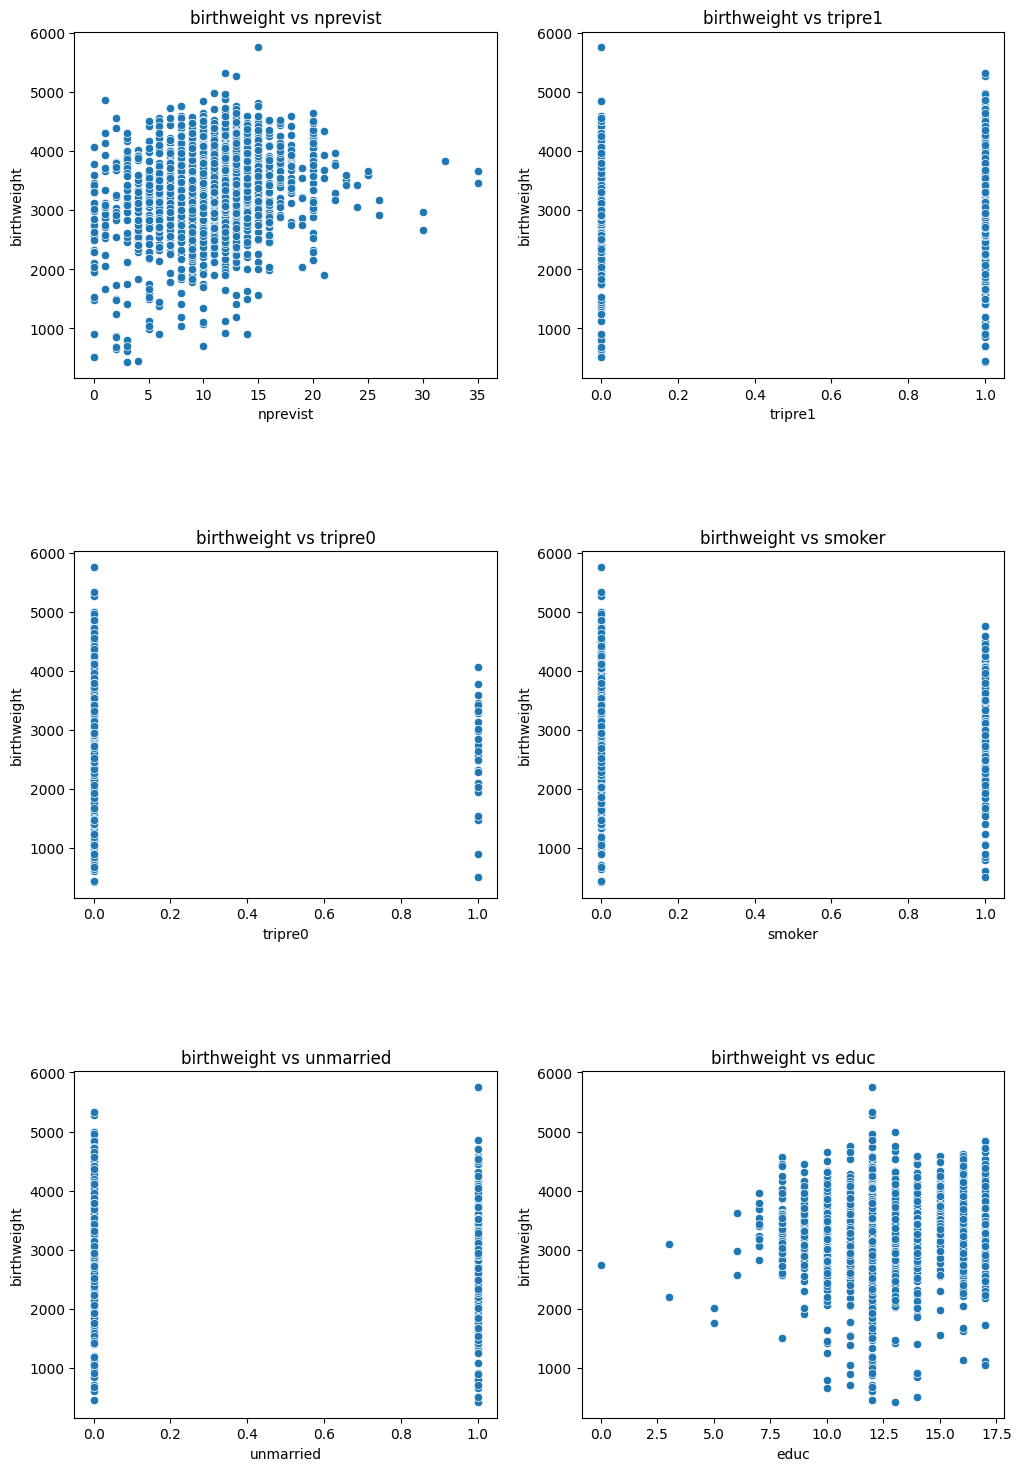

In [8]:

independent_variables = ['nprevist', 'tripre1', 'tripre0', 'smoker', 'unmarried', 'educ']
dependent_variable = 'birthweight'

# Set up subplots
fig, axes = plt.subplots(nrows=len(independent_variables)//2, ncols=2, figsize=(12, 18))
fig.subplots_adjust(hspace=0.5)

for i, var in enumerate(independent_variables):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Scatter plot
    sns.scatterplot(x=var, y=dependent_variable, data=df, ax=ax)
    
    ax.set_title(f'{dependent_variable} vs {var}')
    ax.set_xlabel(var)
    ax.set_ylabel(dependent_variable)

plt.show()

In [ ]:
# Checks for correlation between dependent and independent variables
df.corr()['birthweight']


nprevist       0.227360
alcohol       -0.033647
tripre1        0.112377
tripre2       -0.066714
tripre3       -0.046495
tripre0       -0.123500
birthweight    1.000000
smoker        -0.169127
unmarried     -0.203235
educ           0.105207
age            0.080073
drinks        -0.032409
Name: birthweight, dtype: float64

It seems alcohol, tripre2, tripre3, age, and drinks have a weak corretlation with birthweight so it might be useful to drop them before conducting a linear regression

In [ ]:
#setting birthweight to a new variable name 'weight
weight = df['birthweight']
#dropping the variables I identified earlier
df = df.drop(['alcohol', 'tripre2', 'tripre3', 'age', 'drinks'], axis = 1)
#moving weight to the back of the data set
df['weight'] = weight
df

,nprevist,tripre1,tripre0,birthweight,smoker,unmarried,educ,weight
0,12,1,0,4253.0,1.0,1.0,12.0,4253.0
1,5,0,0,3459.0,0.0,0.0,16.0,3459.0
2,12,1,0,2920.0,1.0,0.0,11.0,2920.0
3,13,1,0,2600.0,0.0,0.0,17.0,2600.0
4,9,1,0,3742.0,0.0,0.0,13.0,3742.0
...,...,...,...,...,...,...,...,...
2995,15,0,0,2520.0,0.0,0.0,12.0,2520.0
2996,10,1,0,3062.0,0.0,0.0,17.0,3062.0
2997,11,0,0,3799.0,0.0,0.0,12.0,3799.0
2998,10,1,0,2070.0,1.0,0.0,11.0,2070.0


In [ ]:
x = df[['nprevist', 'tripre1', 'tripre0', 'smoker', 'unmarried', 'educ']]
y = df['birthweight']
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:            birthweight   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     50.88
Date:                Sun, 10 Dec 2023   Prob (F-statistic):           7.31e-60
Time:                        04:04:24   Log-Likelihood:                -23262.
No. Observations:                3000   AIC:                         4.654e+04
Df Residuals:                    2993   BIC:                         4.658e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3185.5764     74.590     42.708      0.0

We can exclude educ as the p-value is greater than 0.05 meaning we can reject the null hypothesis. We can now form our regression formula 

In [ ]:
#sets all the independent variables as x 
x = df[['nprevist', 'tripre1', 'tripre0', 'smoker', 'unmarried']]
#sets dependent variable as y
y = df['birthweight']
#adds a constant 
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:            birthweight   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     61.08
Date:                Sun, 10 Dec 2023   Prob (F-statistic):           8.88e-61
Time:                        17:23:48   Log-Likelihood:                -23262.
No. Observations:                3000   AIC:                         4.654e+04
Df Residuals:                    2994   BIC:                         4.657e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3187.7104     38.547     82.696      0.0